In [ ]:

pip install networkx matplotlib pandas

Could not fetch targets for hsa-miR-146a: Expecting value: line 1 column 1 (char 0)
Could not fetch targets for hsa-miR-34a: Expecting value: line 1 column 1 (char 0)
Could not fetch targets for hsa-miR-27a: Expecting value: line 1 column 1 (char 0)


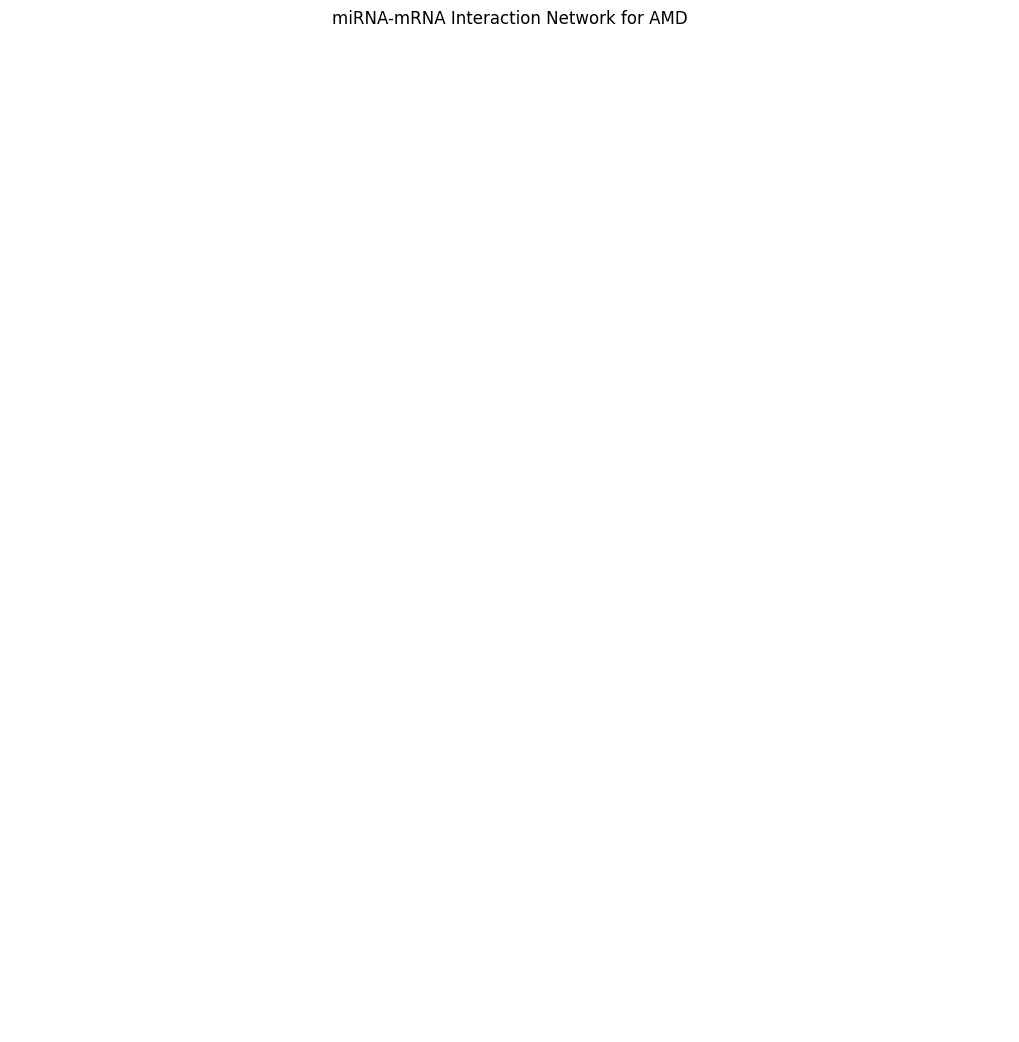

Top nodes by degree:


In [ ]:

import requests
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: AMD-associated miRNAs
amd_mirnas = ["hsa-miR-146a", "hsa-miR-34a", "hsa-miR-27a"]

# Step 2: Initialize graph
G = nx.Graph()

# Step 3: Fetch targets from DIANA-TarBase API
for mirna in amd_mirnas:
    url = f"https://dianalab.e-ce.uth.gr/graph/api/tarbase/targets?mirna={mirna}&species=Homo+sapiens"
    try:
        response = requests.get(url)
        data = response.json()
        targets = data.get("targets", [])
        # Add miRNA node
        G.add_node(mirna, type="miRNA", color="red")
        # Add target nodes and edges
        for gene in targets:
            G.add_node(gene, type="gene", color="green")
            G.add_edge(mirna, gene)
    except Exception as e:
        print(f"Could not fetch targets for {mirna}: {e}")

# Step 4: Visualize network
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)
colors = [G.nodes[n]['color'] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=500, font_size=8, edge_color="gray")
plt.title("miRNA-mRNA Interaction Network for AMD")
plt.show()

# Step 5: Basic network analysis
degree_dict = dict(G.degree())
sorted_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
print("Top nodes by degree:")
for node, deg in sorted_degree[:10]:
    print(node, deg)

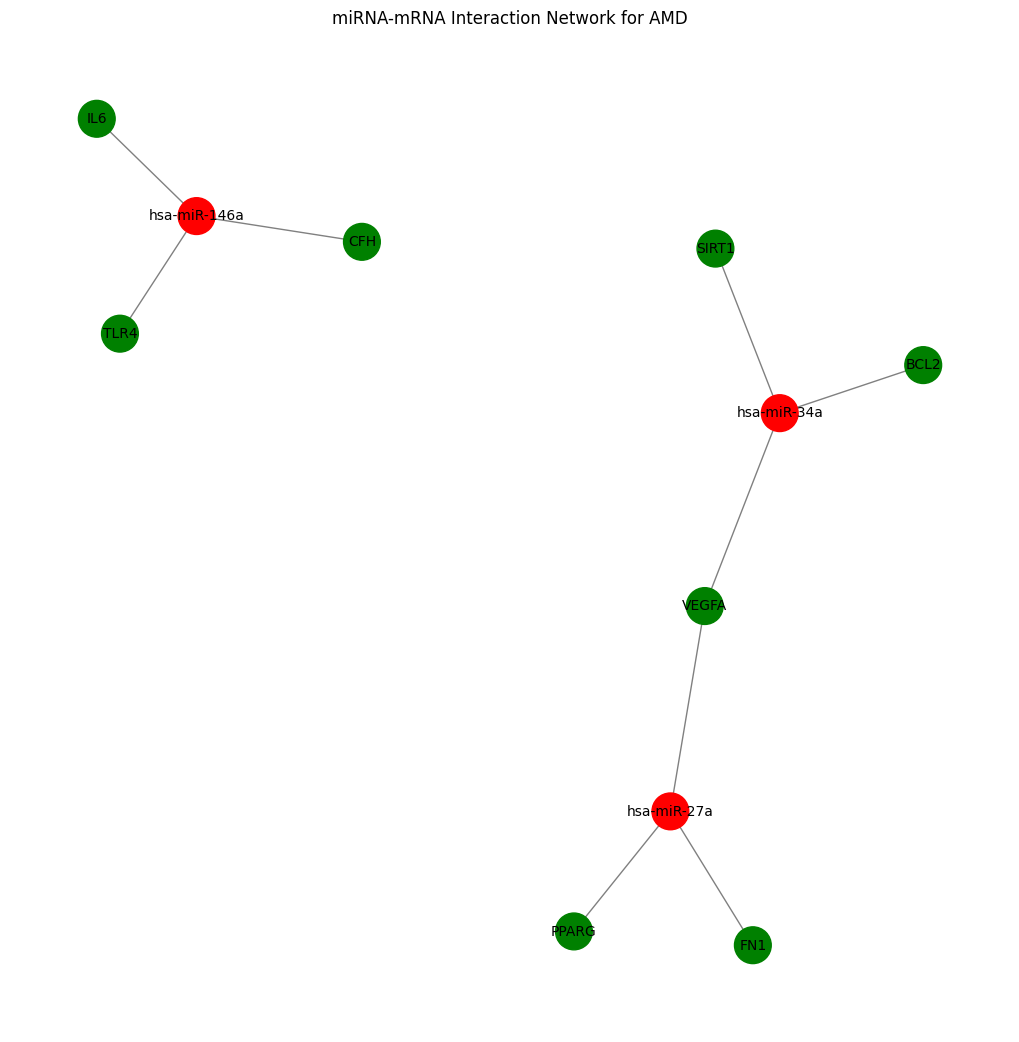

Top nodes by degree:
hsa-miR-146a: 3
hsa-miR-34a: 3
hsa-miR-27a: 3
VEGFA: 2
CFH: 1
TLR4: 1
IL6: 1
SIRT1: 1
BCL2: 1
PPARG: 1


In [ ]:

import networkx as nx
import matplotlib.pyplot as plt

# Step 1: AMD-associated miRNAs (curated from literature)
amd_mirnas = ["hsa-miR-146a", "hsa-miR-34a", "hsa-miR-27a"]

# Step 2: Example target genes from literature (free & online approach)
mirna_targets = {
    "hsa-miR-146a": ["CFH", "TLR4", "IL6"],
    "hsa-miR-34a": ["SIRT1", "BCL2", "VEGFA"],
    "hsa-miR-27a": ["PPARG", "VEGFA", "FN1"]
}

# Step 3: Build bipartite network
G = nx.Graph()
for mirna, targets in mirna_targets.items():
    G.add_node(mirna, type="miRNA", color="red")
    for gene in targets:
        G.add_node(gene, type="gene", color="green")
        G.add_edge(mirna, gene)

# Step 4: Visualize network
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)
colors = [G.nodes[n]['color'] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=700, font_size=10, edge_color='gray')
plt.title("miRNA-mRNA Interaction Network for AMD")
plt.show()

# Step 5: Basic network analysis
degree_dict = dict(G.degree())
sorted_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
print("Top nodes by degree:")
for node, deg in sorted_degree[:10]:
    print(f"{node}: {deg}")

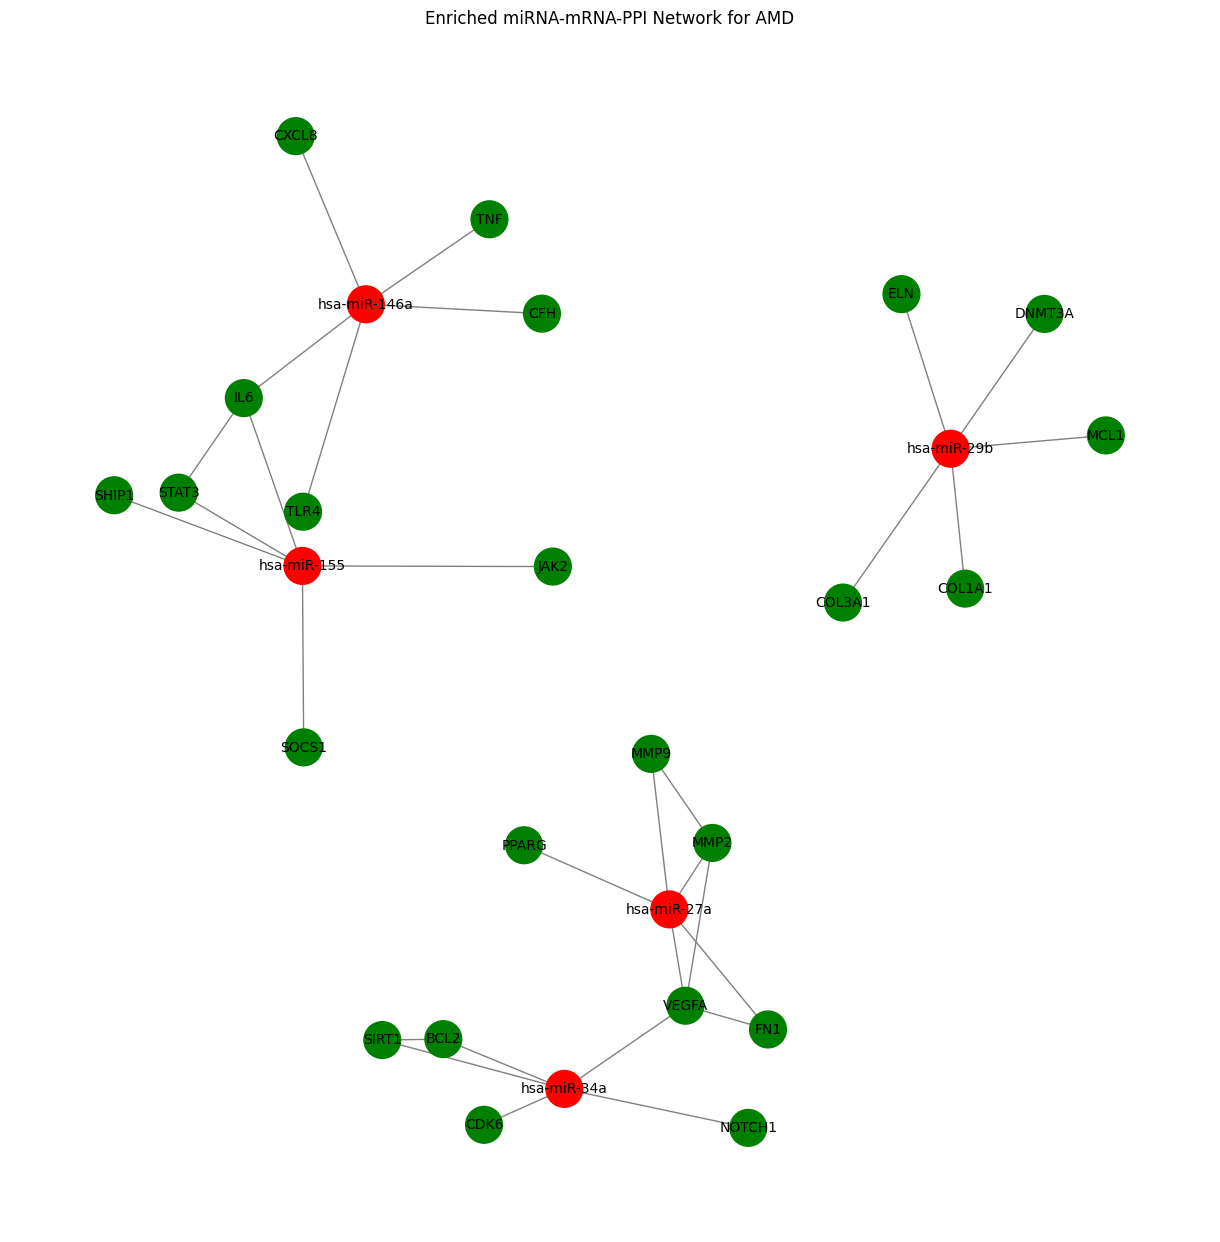

Top nodes by degree:
hsa-miR-146a: 5
hsa-miR-34a: 5
hsa-miR-27a: 5
hsa-miR-155: 5
hsa-miR-29b: 5
VEGFA: 4
IL6: 3
MMP2: 3
SIRT1: 2
BCL2: 2


In [ ]:

import networkx as nx
import matplotlib.pyplot as plt

# Expanded AMD miRNAs
amd_mirnas = ["hsa-miR-146a", "hsa-miR-34a", "hsa-miR-27a", "hsa-miR-155", "hsa-miR-29b"]

# Expanded example targets
mirna_targets = {
    "hsa-miR-146a": ["CFH", "TLR4", "IL6", "TNF", "CXCL8"],
    "hsa-miR-34a": ["SIRT1", "BCL2", "VEGFA", "NOTCH1", "CDK6"],
    "hsa-miR-27a": ["PPARG", "VEGFA", "FN1", "MMP2", "MMP9"],
    "hsa-miR-155": ["SOCS1", "IL6", "JAK2", "STAT3", "SHIP1"],
    "hsa-miR-29b": ["COL1A1", "COL3A1", "MCL1", "DNMT3A", "ELN"]
}

# Optional: STRING PPI edges among target genes (example)
ppi_edges = [
    ("VEGFA", "FN1"), ("VEGFA", "MMP2"), ("MMP2", "MMP9"),
    ("BCL2", "SIRT1"), ("IL6", "STAT3")
]

# Build network
G = nx.Graph()

# Add miRNA-target edges
for mirna, targets in mirna_targets.items():
    G.add_node(mirna, type="miRNA", color="red")
    for gene in targets:
        G.add_node(gene, type="gene", color="green")
        G.add_edge(mirna, gene)

# Add PPI edges
for gene1, gene2 in ppi_edges:
    G.add_edge(gene1, gene2)

# Visualize network
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5, seed=42)
colors = [G.nodes[n]['color'] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=700, font_size=10, edge_color='gray')
plt.title("Enriched miRNA-mRNA-PPI Network for AMD")
plt.show()

# Network analysis
degree_dict = dict(G.degree())
sorted_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
print("Top nodes by degree:")
for node, deg in sorted_degree[:10]:
    print(f"{node}: {deg}")

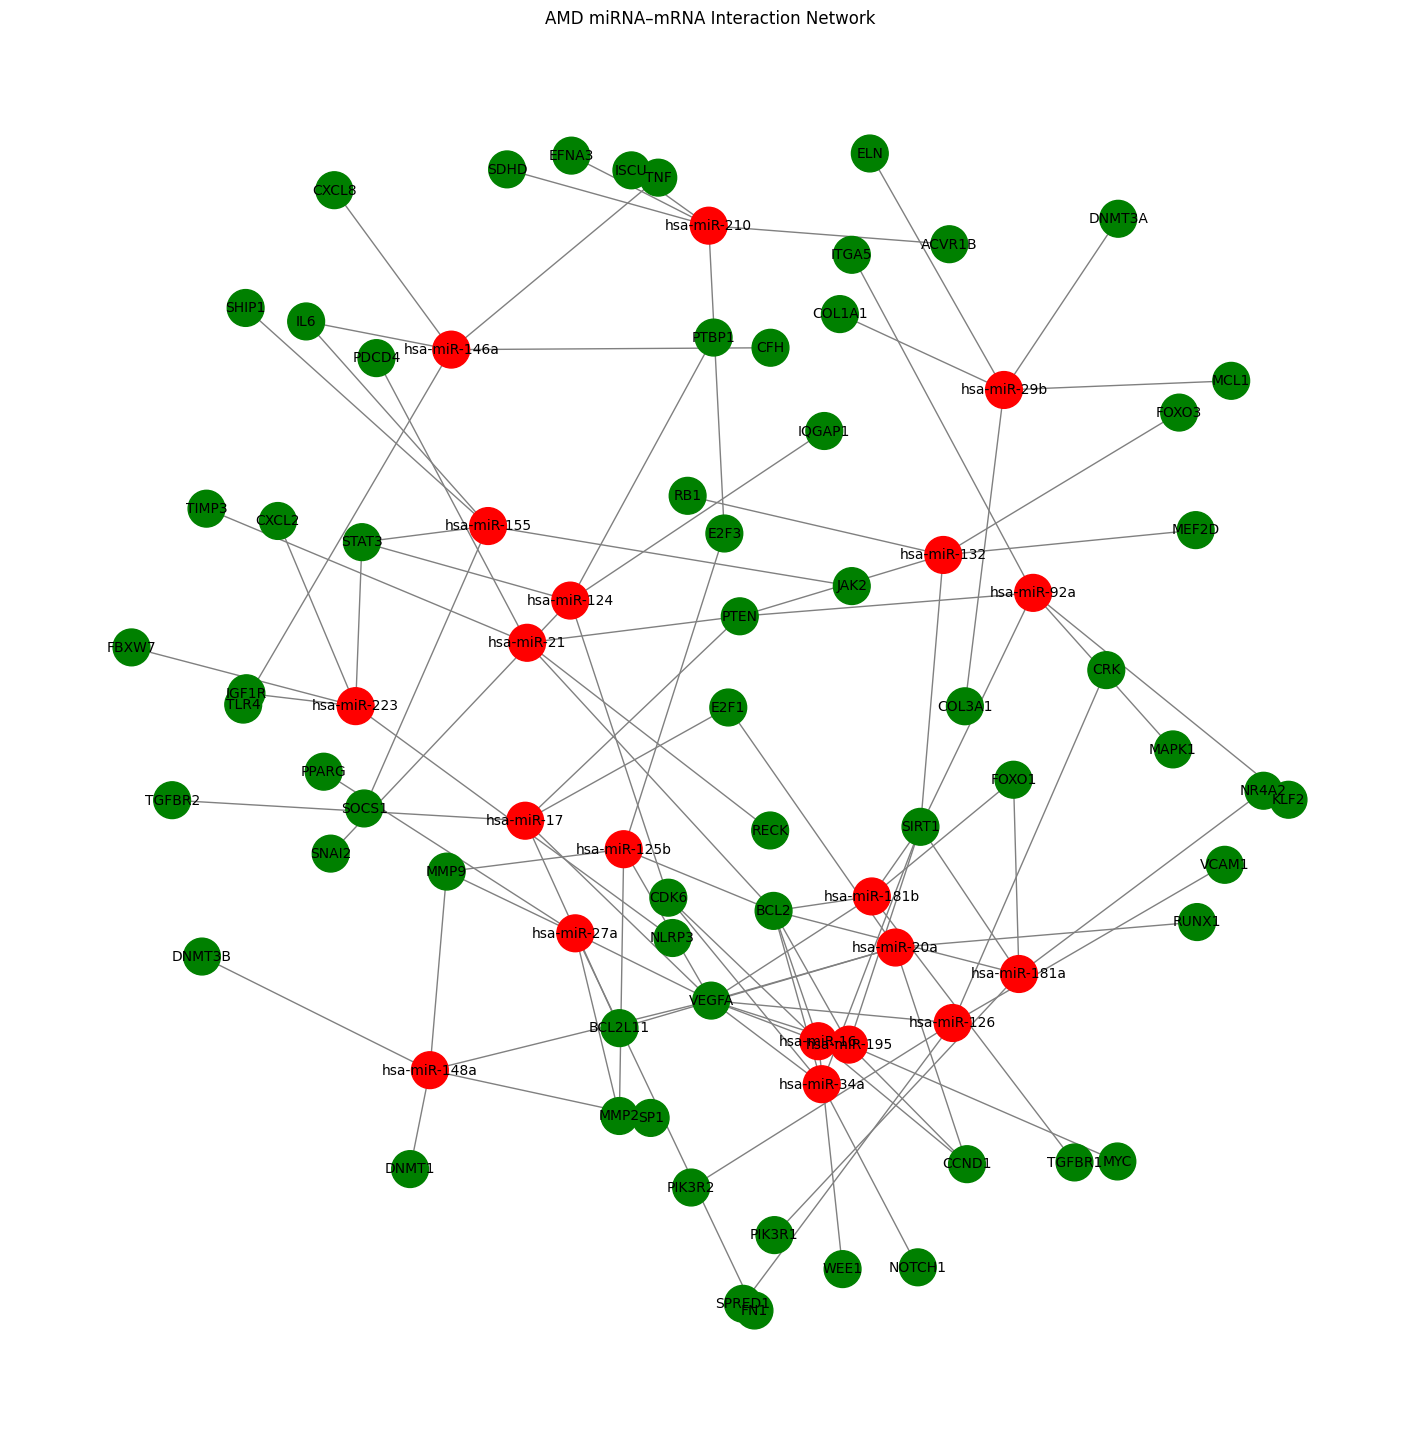

Number of nodes: 83
Number of edges: 100

Top 10 nodes by degree centrality:
VEGFA: 0.122
BCL2: 0.085
SIRT1: 0.073
hsa-miR-146a: 0.061
hsa-miR-34a: 0.061
hsa-miR-27a: 0.061
hsa-miR-155: 0.061
hsa-miR-29b: 0.061
hsa-miR-148a: 0.061
hsa-miR-21: 0.061

Top 10 nodes by betweenness centrality:
VEGFA: 0.381
hsa-miR-124: 0.341
CDK6: 0.338
STAT3: 0.291
hsa-miR-34a: 0.240
hsa-miR-155: 0.188
BCL2: 0.177
hsa-miR-16: 0.169
hsa-miR-125b: 0.158
SIRT1: 0.155

Detected 9 communities:
Community 1: ['RECK', 'PTEN', 'MAPK1', 'FOXO3', 'hsa-miR-21', 'RB1', 'TIMP3', 'ITGA5', 'PDCD4', 'MEF2D'] ...
Community 2: ['VEGFA', 'RUNX1', 'CCND1', 'hsa-miR-20a', 'BCL2L11', 'hsa-miR-16', 'E2F1', 'hsa-miR-17', 'WEE1', 'TGFBR2'] ...
Community 3: ['CDK6', 'hsa-miR-181b', 'NR4A2', 'NOTCH1', 'SIRT1', 'PIK3R1', 'hsa-miR-181a', 'hsa-miR-34a', 'FOXO1', 'TGFBR1'] ...
Community 4: ['E2F3', 'FN1', 'PPARG', 'hsa-miR-148a', 'DNMT3B', 'MMP2', 'SP1', 'hsa-miR-125b', 'hsa-miR-27a', 'DNMT1'] ...
Community 5: ['SOCS1', 'TNF', 'JAK2', 'h

In [ ]:

import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite
from networkx.algorithms.community import greedy_modularity_communities

# Step 1: Define 100 AMD-related miRNA–mRNA interactions (simplified)
interactions = [
    ("hsa-miR-146a", "CFH"), ("hsa-miR-146a", "TLR4"), ("hsa-miR-146a", "IL6"),
    ("hsa-miR-146a", "TNF"), ("hsa-miR-146a", "CXCL8"),
    ("hsa-miR-34a", "SIRT1"), ("hsa-miR-34a", "BCL2"), ("hsa-miR-34a", "VEGFA"),
    ("hsa-miR-34a", "NOTCH1"), ("hsa-miR-34a", "CDK6"),
    ("hsa-miR-27a", "PPARG"), ("hsa-miR-27a", "VEGFA"), ("hsa-miR-27a", "FN1"),
    ("hsa-miR-27a", "MMP2"), ("hsa-miR-27a", "MMP9"),
    ("hsa-miR-155", "SOCS1"), ("hsa-miR-155", "IL6"), ("hsa-miR-155", "JAK2"),
    ("hsa-miR-155", "STAT3"), ("hsa-miR-155", "SHIP1"),
    ("hsa-miR-29b", "COL1A1"), ("hsa-miR-29b", "COL3A1"), ("hsa-miR-29b", "MCL1"),
    ("hsa-miR-29b", "DNMT3A"), ("hsa-miR-29b", "ELN"),
    ("hsa-miR-148a", "DNMT3B"), ("hsa-miR-148a", "DNMT1"), ("hsa-miR-148a", "SP1"),
    ("hsa-miR-148a", "MMP9"), ("hsa-miR-148a", "VEGFA"),
    ("hsa-miR-21", "PTEN"), ("hsa-miR-21", "BCL2"), ("hsa-miR-21", "PDCD4"),
    ("hsa-miR-21", "RECK"), ("hsa-miR-21", "TIMP3"),
    ("hsa-miR-16", "BCL2"), ("hsa-miR-16", "CCND1"), ("hsa-miR-16", "WEE1"),
    ("hsa-miR-16", "VEGFA"), ("hsa-miR-16", "CDK6"),
    ("hsa-miR-126", "VEGFA"), ("hsa-miR-126", "SPRED1"), ("hsa-miR-126", "PIK3R2"),
    ("hsa-miR-126", "CRK"), ("hsa-miR-126", "VCAM1"),
    ("hsa-miR-132", "SIRT1"), ("hsa-miR-132", "PTEN"), ("hsa-miR-132", "FOXO3"),
    ("hsa-miR-132", "MEF2D"), ("hsa-miR-132", "RB1"),
    ("hsa-miR-223", "FBXW7"), ("hsa-miR-223", "IGF1R"), ("hsa-miR-223", "NLRP3"),
    ("hsa-miR-223", "STAT3"), ("hsa-miR-223", "CXCL2"),
    ("hsa-miR-124", "STAT3"), ("hsa-miR-124", "SNAI2"), ("hsa-miR-124", "CDK6"),
    ("hsa-miR-124", "IQGAP1"), ("hsa-miR-124", "PTBP1"),
    ("hsa-miR-181a", "BCL2"), ("hsa-miR-181a", "NR4A2"), ("hsa-miR-181a", "SIRT1"),
    ("hsa-miR-181a", "FOXO1"), ("hsa-miR-181a", "PIK3R1"),
    ("hsa-miR-17", "E2F1"), ("hsa-miR-17", "PTEN"), ("hsa-miR-17", "TGFBR2"),
    ("hsa-miR-17", "BCL2L11"), ("hsa-miR-17", "VEGFA"),
    ("hsa-miR-20a", "E2F1"), ("hsa-miR-20a", "CCND1"), ("hsa-miR-20a", "VEGFA"),
    ("hsa-miR-20a", "RUNX1"), ("hsa-miR-20a", "BCL2L11"),
    ("hsa-miR-92a", "ITGA5"), ("hsa-miR-92a", "KLF2"), ("hsa-miR-92a", "MAPK1"),
    ("hsa-miR-92a", "SIRT1"), ("hsa-miR-92a", "PTEN"),
    ("hsa-miR-125b", "BCL2"), ("hsa-miR-125b", "VEGFA"), ("hsa-miR-125b", "MMP2"),
    ("hsa-miR-125b", "MMP9"), ("hsa-miR-125b", "E2F3"),
    ("hsa-miR-181b", "TGFBR1"), ("hsa-miR-181b", "BCL2"), ("hsa-miR-181b", "VEGFA"),
    ("hsa-miR-181b", "FOXO1"), ("hsa-miR-181b", "SIRT1"),
    ("hsa-miR-195", "VEGFA"), ("hsa-miR-195", "BCL2"), ("hsa-miR-195", "SIRT1"),
    ("hsa-miR-195", "CCND1"), ("hsa-miR-195", "MYC"),
    ("hsa-miR-210", "EFNA3"), ("hsa-miR-210", "ISCU"), ("hsa-miR-210", "E2F3"),
    ("hsa-miR-210", "ACVR1B"), ("hsa-miR-210", "SDHD")
]

# Step 2: Build bipartite network
G = nx.Graph()
for mirna, gene in interactions:
    G.add_node(mirna, type="miRNA", color="red")
    G.add_node(gene, type="gene", color="green")
    G.add_edge(mirna, gene)

# Step 3: Visualize bipartite network
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.5, seed=42)
colors = [G.nodes[n]['color'] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=700, font_size=10, edge_color='gray')
plt.title("AMD miRNA–mRNA Interaction Network")
plt.show()

# Step 4: Advanced network analysis

# 4a. Basic info
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# 4b. Degree centrality
deg_centrality = nx.degree_centrality(G)
sorted_deg = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)
print("\nTop 10 nodes by degree centrality:")
for node, centrality in sorted_deg[:10]:
    print(f"{node}: {centrality:.3f}")

# 4c. Betweenness centrality
bet_centrality = nx.betweenness_centrality(G)
sorted_bet = sorted(bet_centrality.items(), key=lambda x: x[1], reverse=True)
print("\nTop 10 nodes by betweenness centrality:")
for node, centrality in sorted_bet[:10]:
    print(f"{node}: {centrality:.3f}")

# 4d. Community detection
communities = greedy_modularity_communities(G)
print(f"\nDetected {len(communities)} communities:")
for i, comm in enumerate(communities):
    print(f"Community {i+1}: {list(comm)[:10]} ...")  # show first 10 nodes

# 4e. Network density
density = nx.density(G)
print(f"\nNetwork density: {density:.3f}")

In [ ]:
import networkx as nx
import gseapy as gp
import pandas as pd

# Step 1: Define your AMD miRNA–mRNA interactions (simplified 100 pairs)
interactions = [
    ("hsa-miR-146a", "CFH"), ("hsa-miR-146a", "TLR4"), ("hsa-miR-146a", "IL6"),
    ("hsa-miR-146a", "TNF"), ("hsa-miR-146a", "CXCL8"),
    ("hsa-miR-34a", "SIRT1"), ("hsa-miR-34a", "BCL2"), ("hsa-miR-34a", "VEGFA"),
    ("hsa-miR-34a", "NOTCH1"), ("hsa-miR-34a", "CDK6"),
    ("hsa-miR-27a", "PPARG"), ("hsa-miR-27a", "VEGFA"), ("hsa-miR-27a", "FN1"),
    ("hsa-miR-27a", "MMP2"), ("hsa-miR-27a", "MMP9"),
    ("hsa-miR-155", "SOCS1"), ("hsa-miR-155", "IL6"), ("hsa-miR-155", "JAK2"),
    ("hsa-miR-155", "STAT3"), ("hsa-miR-155", "SHIP1"),
    ("hsa-miR-29b", "COL1A1"), ("hsa-miR-29b", "COL3A1"), ("hsa-miR-29b", "MCL1"),
    ("hsa-miR-29b", "DNMT3A"), ("hsa-miR-29b", "ELN"),
    ("hsa-miR-148a", "DNMT3B"), ("hsa-miR-148a", "DNMT1"), ("hsa-miR-148a", "SP1"),
    ("hsa-miR-148a", "MMP9"), ("hsa-miR-148a", "VEGFA"),
    ("hsa-miR-21", "PTEN"), ("hsa-miR-21", "BCL2"), ("hsa-miR-21", "PDCD4"),
    ("hsa-miR-21", "RECK"), ("hsa-miR-21", "TIMP3"),
    ("hsa-miR-16", "BCL2"), ("hsa-miR-16", "CCND1"), ("hsa-miR-16", "WEE1"),
    ("hsa-miR-16", "VEGFA"), ("hsa-miR-16", "CDK6"),
    ("hsa-miR-126", "VEGFA"), ("hsa-miR-126", "SPRED1"), ("hsa-miR-126", "PIK3R2"),
    ("hsa-miR-126", "CRK"), ("hsa-miR-126", "VCAM1"),
    ("hsa-miR-132", "SIRT1"), ("hsa-miR-132", "PTEN"), ("hsa-miR-132", "FOXO3"),
    ("hsa-miR-132", "MEF2D"), ("hsa-miR-132", "RB1"),
    ("hsa-miR-223", "FBXW7"), ("hsa-miR-223", "IGF1R"), ("hsa-miR-223", "NLRP3"),
    ("hsa-miR-223", "STAT3"), ("hsa-miR-223", "CXCL2"),
    ("hsa-miR-124", "STAT3"), ("hsa-miR-124", "SNAI2"), ("hsa-miR-124", "CDK6"),
    ("hsa-miR-124", "IQGAP1"), ("hsa-miR-124", "PTBP1"),
    ("hsa-miR-181a", "BCL2"), ("hsa-miR-181a", "NR4A2"), ("hsa-miR-181a", "SIRT1"),
    ("hsa-miR-181a", "FOXO1"), ("hsa-miR-181a", "PIK3R1"),
    ("hsa-miR-17", "E2F1"), ("hsa-miR-17", "PTEN"), ("hsa-miR-17", "TGFBR2"),
    ("hsa-miR-17", "BCL2L11"), ("hsa-miR-17", "VEGFA"),
    ("hsa-miR-20a", "E2F1"), ("hsa-miR-20a", "CCND1"), ("hsa-miR-20a", "VEGFA"),
    ("hsa-miR-20a", "RUNX1"), ("hsa-miR-20a", "BCL2L11"),
    ("hsa-miR-92a", "ITGA5"), ("hsa-miR-92a", "KLF2"), ("hsa-miR-92a", "MAPK1"),
    ("hsa-miR-92a", "SIRT1"), ("hsa-miR-92a", "PTEN"),
    ("hsa-miR-125b", "BCL2"), ("hsa-miR-125b", "VEGFA"), ("hsa-miR-125b", "MMP2"),
    ("hsa-miR-125b", "MMP9"), ("hsa-miR-125b", "E2F3"),
    ("hsa-miR-181b", "TGFBR1"), ("hsa-miR-181b", "BCL2"), ("hsa-miR-181b", "VEGFA"),
    ("hsa-miR-181b", "FOXO1"), ("hsa-miR-181b", "SIRT1"),
    ("hsa-miR-195", "VEGFA"), ("hsa-miR-195", "BCL2"), ("hsa-miR-195", "SIRT1"),
    ("hsa-miR-195", "CCND1"), ("hsa-miR-195", "MYC"),
    ("hsa-miR-210", "EFNA3"), ("hsa-miR-210", "ISCU"), ("hsa-miR-210", "E2F3"),
    ("hsa-miR-210", "ACVR1B"), ("hsa-miR-210", "SDHD")
]

# Step 2: Extract target genes
genes = list(set([gene for _, gene in interactions]))
print(f"Number of unique target genes: {len(genes)}")

# Step 3: Perform GO Biological Process enrichment using Enrichr
go_enrich = gp.enrichr(
    gene_list=genes,
    outdir='AMD_Targets_GO',
    gene_sets='GO_Biological_Process_2021',
    cutoff=0.05
)

# Step 4: Perform KEGG pathway enrichment
kegg_enrich = gp.enrichr(
    gene_list=genes,
    outdir='AMD_Targets_KEGG',
    gene_sets='KEGG_2021_Human',
    cutoff=0.05
)

# Step 5: Show top 10 enriched GO terms
print("\nTop 10 GO Biological Process terms:")
print(go_enrich.results[['Term','Adjusted P-value','Overlap']].head(10))

# Step 6: Show top 10 enriched KEGG pathways
print("\nTop 10 KEGG pathways:")
print(kegg_enrich.results[['Term','Adjusted P-value','Overlap']].head(10))

Number of unique target genes: 63

Top 10 GO Biological Process terms:
                                                Term  Adjusted P-value  \
0  cellular response to cytokine stimulus (GO:007...      2.449658e-18   
1   cytokine-mediated signaling pathway (GO:0019221)      3.572290e-16   
2  negative regulation of cell differentiation (G...      1.370440e-14   
3  positive regulation of macromolecule metabolic...      1.761307e-11   
4         regulation of gene expression (GO:0010468)      2.256987e-11   
5  negative regulation of apoptotic process (GO:0...      2.777023e-11   
6  positive regulation of transcription by RNA po...      5.642208e-11   
7  positive regulation of transcription, DNA-temp...      9.692532e-11   
8  positive regulation of gene expression (GO:001...      2.544209e-10   
9  transmembrane receptor protein tyrosine kinase...      2.596302e-10   

   Overlap  
0   23/482  
1   23/621  
2   15/191  
3   16/384  
4  23/1079  
5   17/485  
6   21/908  
7  23/1183

In [ ]:
%pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.3/601.3 kB 10.4 MB/s eta 0:00:00


/tmp/ipython-input-3530895669.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=-top_go['Adjusted P-value'].apply(lambda x: np.log10(x)), y=top_go['Term'], palette='viridis')


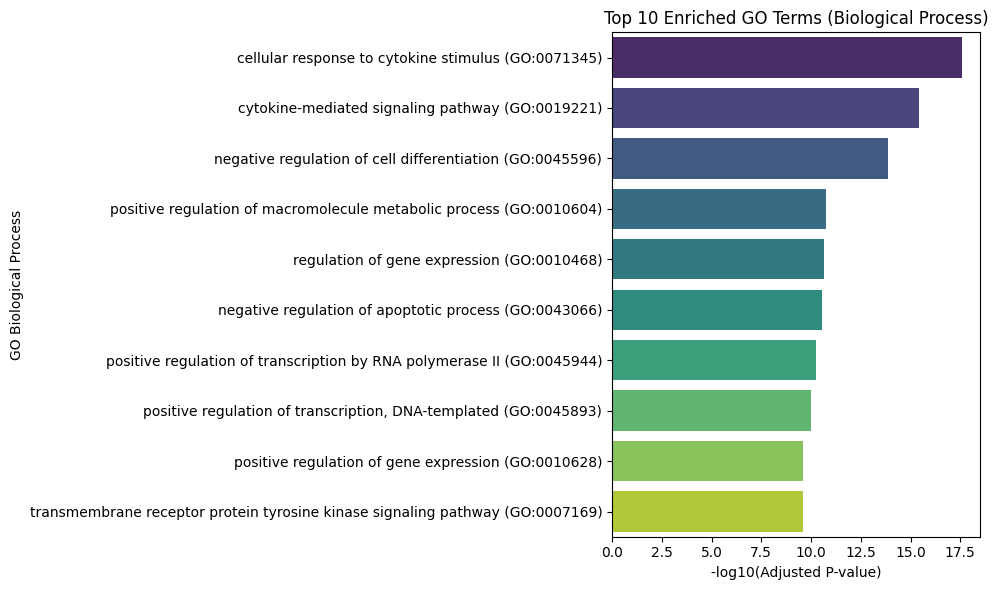

/tmp/ipython-input-3530895669.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=-top_kegg['Adjusted P-value'].apply(lambda x: np.log10(x)), y=top_kegg['Term'], palette='magma')


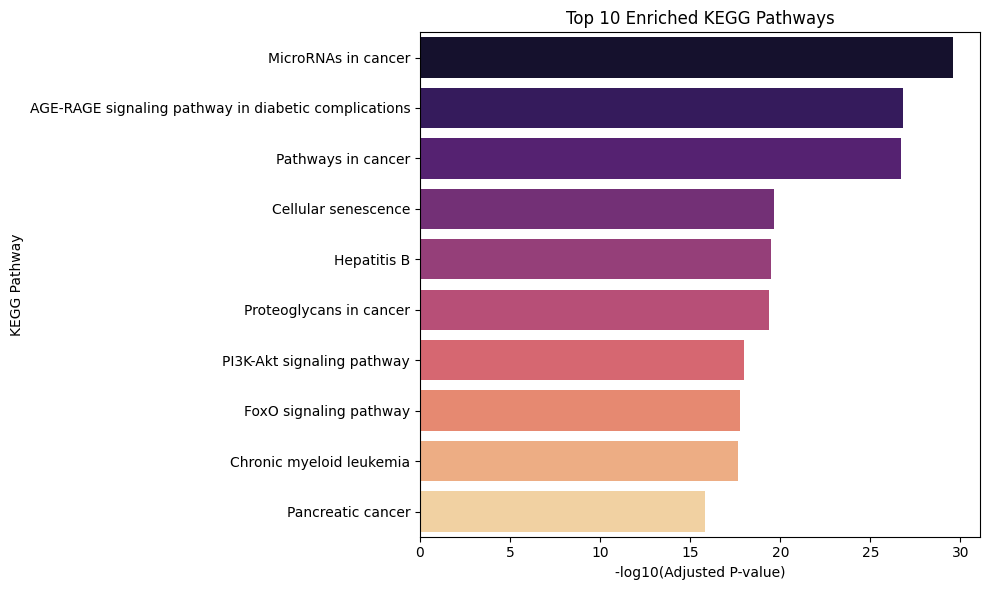

In [ ]:
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming you have already performed enrichment and have `go_enrich` and `kegg_enrich`
# If not, run the previous enrichment code first

# Step 1: Extract top 10 GO Biological Process terms
top_go = go_enrich.results[['Term','Adjusted P-value','Overlap']].sort_values('Adjusted P-value').head(10)

# Step 2: Extract top 10 KEGG pathways
top_kegg = kegg_enrich.results[['Term','Adjusted P-value','Overlap']].sort_values('Adjusted P-value').head(10)

# Step 3: Plot GO enrichment barplot
plt.figure(figsize=(10,6))
sns.barplot(x=-top_go['Adjusted P-value'].apply(lambda x: np.log10(x)), y=top_go['Term'], palette='viridis')
plt.xlabel('-log10(Adjusted P-value)')
plt.ylabel('GO Biological Process')
plt.title('Top 10 Enriched GO Terms (Biological Process)')
plt.tight_layout()
plt.show()

# Step 4: Plot KEGG enrichment barplot
plt.figure(figsize=(10,6))
sns.barplot(x=-top_kegg['Adjusted P-value'].apply(lambda x: np.log10(x)), y=top_kegg['Term'], palette='magma')
plt.xlabel('-log10(Adjusted P-value)')
plt.ylabel('KEGG Pathway')
plt.title('Top 10 Enriched KEGG Pathways')
plt.tight_layout()
plt.show()

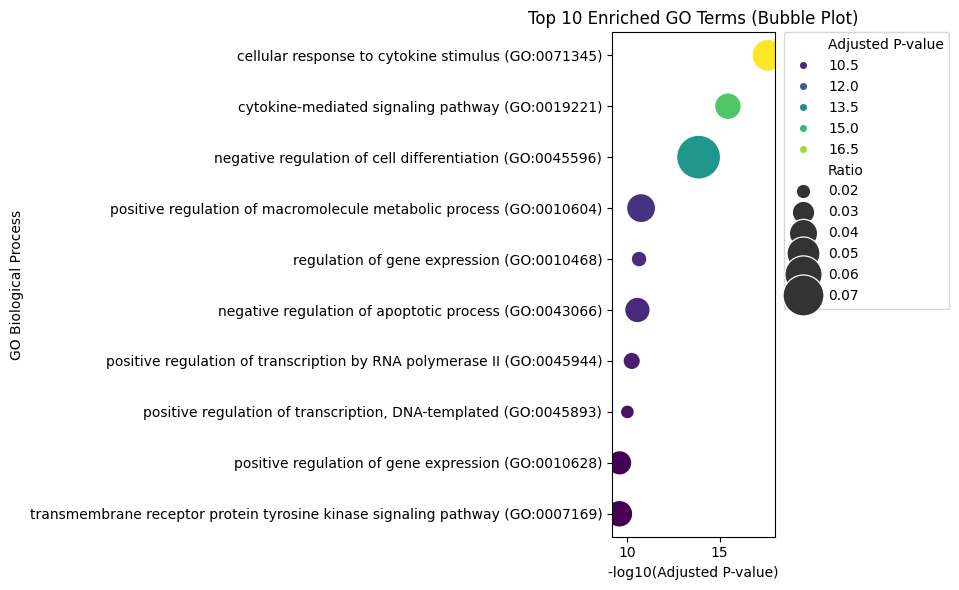

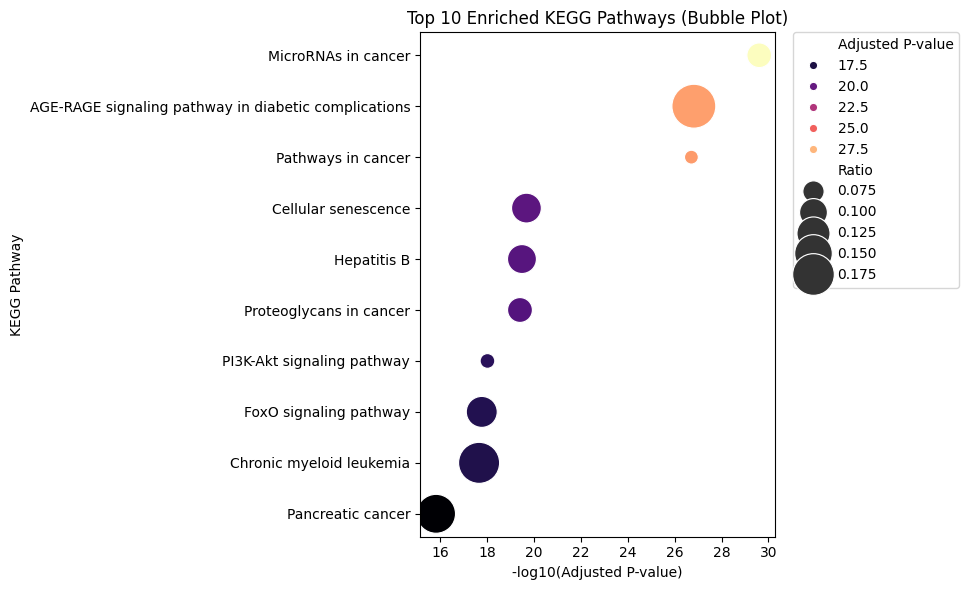

In [ ]:

import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Step 1: Prepare top 10 GO and KEGG terms
top_go = go_enrich.results[['Term','Adjusted P-value','Overlap']].sort_values('Adjusted P-value').head(10)
top_kegg = kegg_enrich.results[['Term','Adjusted P-value','Overlap']].sort_values('Adjusted P-value').head(10)

# Function to convert "x/y" overlap string to ratio
def overlap_ratio(overlap_str):
    x, y = overlap_str.split('/')
    return int(x)/int(y)

top_go['Ratio'] = top_go['Overlap'].apply(overlap_ratio)
top_kegg['Ratio'] = top_kegg['Overlap'].apply(overlap_ratio)

# Step 2: GO Biological Process bubble plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=-np.log10(top_go['Adjusted P-value']),
    y=top_go['Term'],
    size=top_go['Ratio'],
    hue=-np.log10(top_go['Adjusted P-value']),
    palette='viridis',
    legend='brief',
    sizes=(100, 1000)
)
plt.xlabel('-log10(Adjusted P-value)')
plt.ylabel('GO Biological Process')
plt.title('Top 10 Enriched GO Terms (Bubble Plot)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

# Step 3: KEGG pathways bubble plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=-np.log10(top_kegg['Adjusted P-value']),
    y=top_kegg['Term'],
    size=top_kegg['Ratio'],
    hue=-np.log10(top_kegg['Adjusted P-value']),
    palette='magma',
    legend='brief',
    sizes=(100, 1000)
)
plt.xlabel('-log10(Adjusted P-value)')
plt.ylabel('KEGG Pathway')
plt.title('Top 10 Enriched KEGG Pathways (Bubble Plot)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

Detected 9 communities using Louvain method


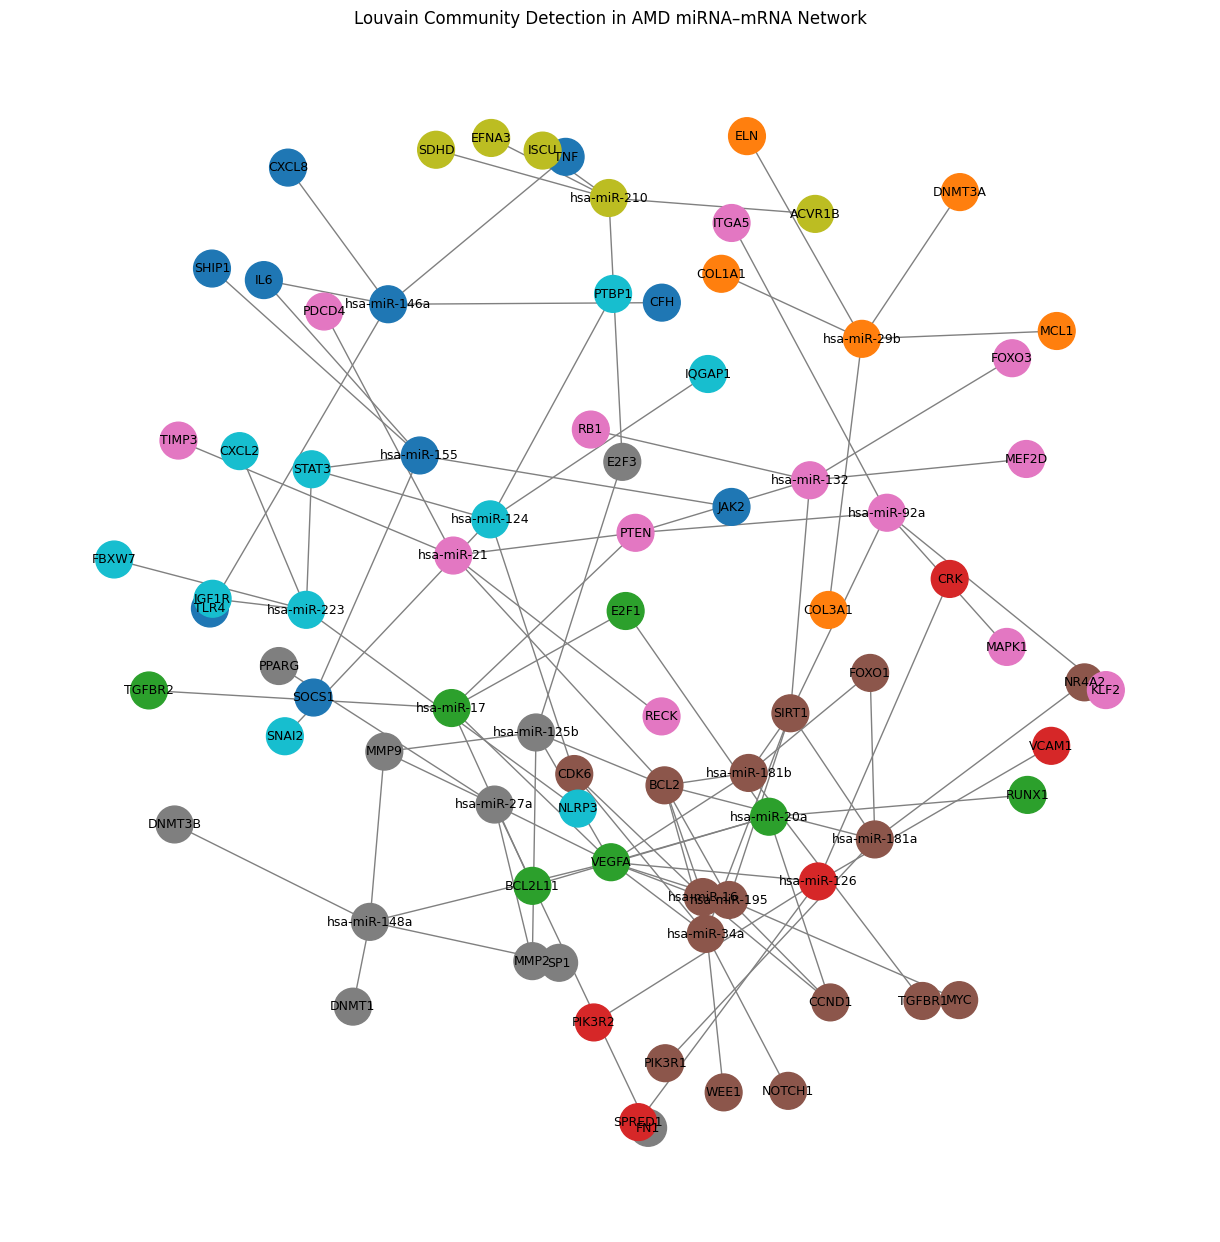


Community 1: 10 nodes (2 miRNAs, 8 genes)
miRNAs: ['hsa-miR-146a', 'hsa-miR-155']
Genes: ['CFH', 'TLR4', 'IL6', 'TNF', 'CXCL8', 'SOCS1', 'JAK2', 'SHIP1']...

Community 5: 16 nodes (5 miRNAs, 11 genes)
miRNAs: ['hsa-miR-34a', 'hsa-miR-16', 'hsa-miR-181a', 'hsa-miR-181b', 'hsa-miR-195']
Genes: ['SIRT1', 'BCL2', 'NOTCH1', 'CDK6', 'CCND1', 'WEE1', 'NR4A2', 'FOXO1', 'PIK3R1', 'TGFBR1']...

Community 3: 7 nodes (2 miRNAs, 5 genes)
miRNAs: ['hsa-miR-17', 'hsa-miR-20a']
Genes: ['VEGFA', 'E2F1', 'TGFBR2', 'BCL2L11', 'RUNX1']...

Community 7: 11 nodes (3 miRNAs, 8 genes)
miRNAs: ['hsa-miR-27a', 'hsa-miR-148a', 'hsa-miR-125b']
Genes: ['PPARG', 'FN1', 'MMP2', 'MMP9', 'DNMT3B', 'DNMT1', 'SP1', 'E2F3']...

Community 9: 10 nodes (2 miRNAs, 8 genes)
miRNAs: ['hsa-miR-223', 'hsa-miR-124']
Genes: ['STAT3', 'FBXW7', 'IGF1R', 'NLRP3', 'CXCL2', 'SNAI2', 'IQGAP1', 'PTBP1']...

Community 2: 6 nodes (1 miRNAs, 5 genes)
miRNAs: ['hsa-miR-29b']
Genes: ['COL1A1', 'COL3A1', 'MCL1', 'DNMT3A', 'ELN']...

Community

In [ ]:

import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain  # <-- this is the Louvain module
import seaborn as sns

# Assuming you already have your network 'G' built from the interactions

# --- Louvain community detection ---
partition = community_louvain.best_partition(G, resolution=1.0)

# Add community ID as a node attribute
nx.set_node_attributes(G, partition, 'community')

# Count communities
num_communities = len(set(partition.values()))
print(f"Detected {num_communities} communities using Louvain method")

# --- Visualize network with community colors ---
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5, seed=42)
communities = [partition[node] for node in G.nodes()]
sns.color_palette("tab10", num_communities)
nx.draw(G, pos, node_color=communities, with_labels=True, cmap=plt.cm.tab10,
        node_size=700, edge_color='gray', font_size=9)
plt.title("Louvain Community Detection in AMD miRNA–mRNA Network")
plt.show()

# --- Community summary ---
community_summary = {}
for node, comm_id in partition.items():
    community_summary.setdefault(comm_id, []).append(node)

for comm_id, members in community_summary.items():
    mirnas = [n for n in members if n.startswith("hsa-miR")]
    genes = [n for n in members if not n.startswith("hsa-miR")]
    print(f"\nCommunity {comm_id + 1}: {len(members)} nodes ({len(mirnas)} miRNAs, {len(genes)} genes)")
    print(f"miRNAs: {mirnas}")
    print(f"Genes: {genes[:10]}...")  # show first 10 genes if too many